In [1]:
import re
import numpy as np
import assembly_pool as ap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
a = ap.AssemblyPool(25,25)
evolution = a.evolve(8000)

Calculating iterations: 100%|██████████| 8000/8000 [00:57<00:00, 138.66it/s]


In [3]:
a.pool['size'] = a.pool.element.str.len() 
a.pool['balanced'] = np.abs(a.pool.element.str.count("0") - a.pool.element.str.count("1"))<= 1
a.pool.tail(20)

,element,copy_number,size,balanced,dyck_word,entropy,assembly,assembly_efficiency,history,steps,lz_comp,has_inversion,ensemble
7736,1001001100111001000111001101111001001100111110...,1,868,False,False,0.999812,12,1.833333,((((((((((((((((((((1)(0))(0))(1))(0))(0))(1))...,22,149,False,0.00011
7737,1001000111101001010010011001111001001111011100...,1,287,False,False,0.999571,9,2.111111,((((((((((((((((((((1)(0))(0))(1))(0))(0))((0)...,19,63,False,0.00011
7738,1001000111101001001100111110111011101001111111...,1,124,False,False,0.998310,9,1.555556,(((((((((((((((1)(0))(0))(1))(0))(0))((0)(1)))...,14,34,False,0.00011
7739,1001000111101001001100111001001100111110111110...,1,319,False,False,0.999426,9,2.000000,((((((((((((((((1)(0))(0))(1))(0))(0))((0)(1))...,18,67,False,0.00011
7740,1001000111101001001100110010010011001110010001...,1,531,False,False,0.999690,11,2.181818,(((((((((((((((((((((((1)(0))(0))(1))(0))(0))(...,24,100,False,0.00011
7741,1001000111101001001100111001001100111110111100...,1,1043,False,False,0.997021,12,1.833333,((((((((((((((((((((((1)(0))(0))(1))(0))(0))((...,22,172,False,0.00011
7742,1001000111101001001100111001001100111110111001...,1,203,False,False,0.999842,9,1.666667,((((((((((((((((1)(0))(0))(1))(0))(0))((0)(1))...,15,48,False,0.00011
7743,10010001111011101110000111110011,1,32,False,False,0.974489,6,1.833333,((((((((((((1)(0))(0))(1))(0))(0))((0)(1)))((1...,11,11,False,0.00011
7744,1001000111101001001100111001001100111110111001...,1,629,True,False,0.999998,12,1.583333,(((((((((((((((((((1)(0))(0))(1))(0))(0))((0)(...,19,116,False,0.00011
7745,0001100111111010111111110010111001001000111101...,1,262,False,False,0.997308,11,1.727273,(((((((((((((((((((0)(0))(0))(1))((((1)(0))(0)...,19,58,False,0.00011


In [4]:
evolution.tail(20)

,count,count_balanced,count_dyck_words,max_size,max_steps,max_lz_comp,assembly_ceiling,ensemble_entropy
781,7556,352,192,98228,26,224,14,12.452927
782,7566,353,192,98358,26,224,14,12.455296
783,7576,353,192,98488,26,224,14,12.457661
784,7586,353,192,98618,26,224,14,12.460022
785,7596,353,192,98748,26,224,14,12.462380
786,7606,353,192,98878,26,224,14,12.464735
787,7616,353,192,99008,26,224,14,12.467086
788,7626,353,192,99138,26,224,14,12.469434
789,7636,353,192,99268,26,224,14,12.471778
790,7646,353,192,99398,26,224,14,12.474119


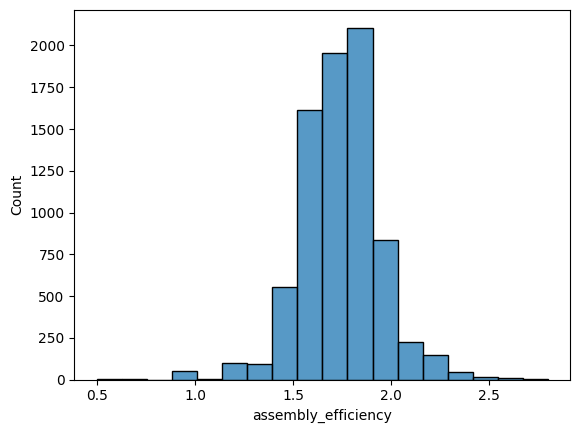

In [5]:
sns.histplot(a.pool.assembly_efficiency, bins=18)
plt.show()

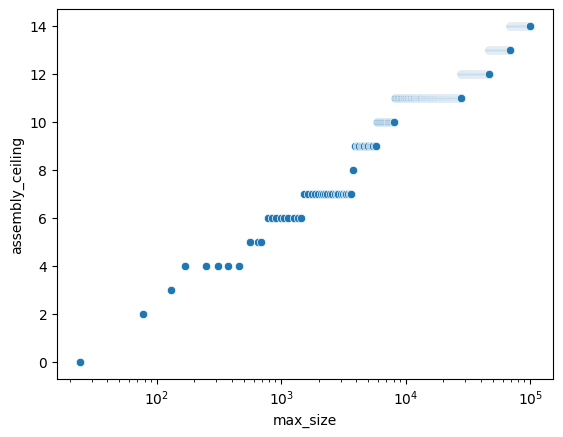

In [6]:

sns.scatterplot(data=evolution,x="max_size",y="assembly_ceiling")
plt.xscale("log")
plt.show()

In [7]:
a.pool[a.pool.assembly_efficiency < 1]

,element,copy_number,size,balanced,dyck_word,entropy,assembly,assembly_efficiency,history,steps,lz_comp,has_inversion,ensemble
2,10,1,2,True,False,1.0,2,0.500000,((1)(0)),1,2,False,0.000110
3,00,12,2,False,False,0.0,2,0.500000,((0)(0)),1,1,False,0.001321
4,01,1,2,True,False,1.0,2,0.500000,((0)(1)),1,2,True,0.000110
10,11,11,2,False,False,0.0,2,0.500000,((1)(1)),1,1,True,0.001211
92,1100,1,4,True,False,1.0,3,0.666667,(((1)(1))((0)(0))),2,3,True,0.000110


Assembly Index: 0, Tk:2
Assembly Index: 1, Tk:2
Assembly Index: 2, Tk:3
Assembly Index: 3, Tk:4
Assembly Index: 4, Tk:9
Assembly Index: 5, Tk:12
Assembly Index: 6, Tk:21
Assembly Index: 7, Tk:42
Assembly Index: 8, Tk:43
Assembly Index: 9, Tk:60
Assembly Index: 10, Tk:80
Assembly Index: 11, Tk:237
Assembly Index: 12, Tk:384
Assembly Index: 13, Tk:558


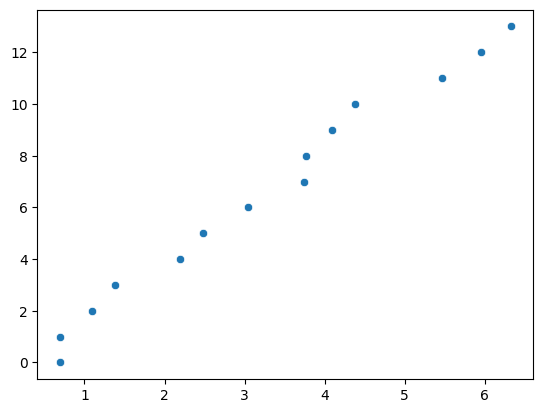

In [ ]:
data = np.zeros([np.max(evolution.assembly_ceiling),2])
for i in range(np.max(evolution.assembly_ceiling)):
    tk = np.min(evolution[evolution.assembly_ceiling > i].index)

    data[i,0] = tk
    data[i,1] = i
    print(f"Assembly Index: {i}, Tk:{np.min(evolution[evolution.assembly_ceiling> i].index)}")
data



sns.scatterplot(x = np.log(data[:,0]), y = data[:,1])
dd
plt.show()